In [2]:
import pandas as pd
df = pd.read_csv(r"diabetes.csv")

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from scikit_learn.linear import linear

In [4]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [8]:
df.shape


(768, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: xlabel='Insulin'>

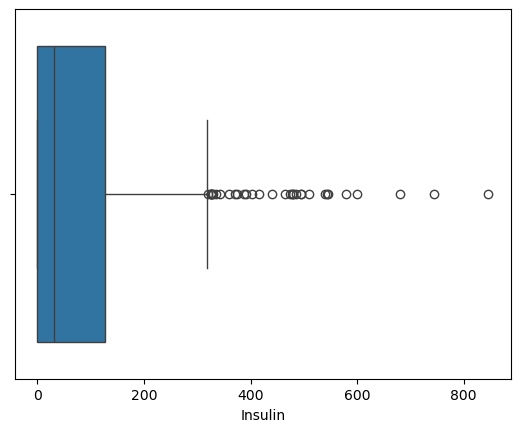

In [11]:
sns.boxplot(x =df['Insulin'])

In [12]:
df['Insulin'].value_counts()

Insulin
0      374
105     11
130      9
140      9
120      8
      ... 
73       1
171      1
255      1
52       1
112      1
Name: count, Length: 186, dtype: int64

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

# 1. Identify all columns where 0 is an invalid biological placeholder
zero_missing_cols = ['Insulin', 'SkinThickness', 'Glucose', 'BloodPressure', 'BMI']

# 2. Replace 0s with np.nan across all identified columns at once
df[zero_missing_cols] = df[zero_missing_cols].replace(0, np.nan)

# 3. Separate features and target
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 4. Train-Test Split (Crucial to do BEFORE imputation to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Apply the KNN Imputer
imputer = KNNImputer(n_neighbors=5)

# Fit on training data, transform both subsets
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [14]:
df['SkinThickness'].value_counts()

SkinThickness
0     227
32     31
30     27
27     23
23     22
33     20
28     20
18     20
31     19
19     18
39     18
29     17
40     16
25     16
26     16
22     16
37     16
41     15
35     15
36     14
15     14
17     14
20     13
24     12
42     11
13     11
21     10
46      8
34      8
12      7
38      7
11      6
43      6
16      6
45      6
14      6
44      5
10      5
48      4
47      4
49      3
50      3
8       2
7       2
52      2
54      2
63      1
60      1
56      1
51      1
99      1
Name: count, dtype: int64

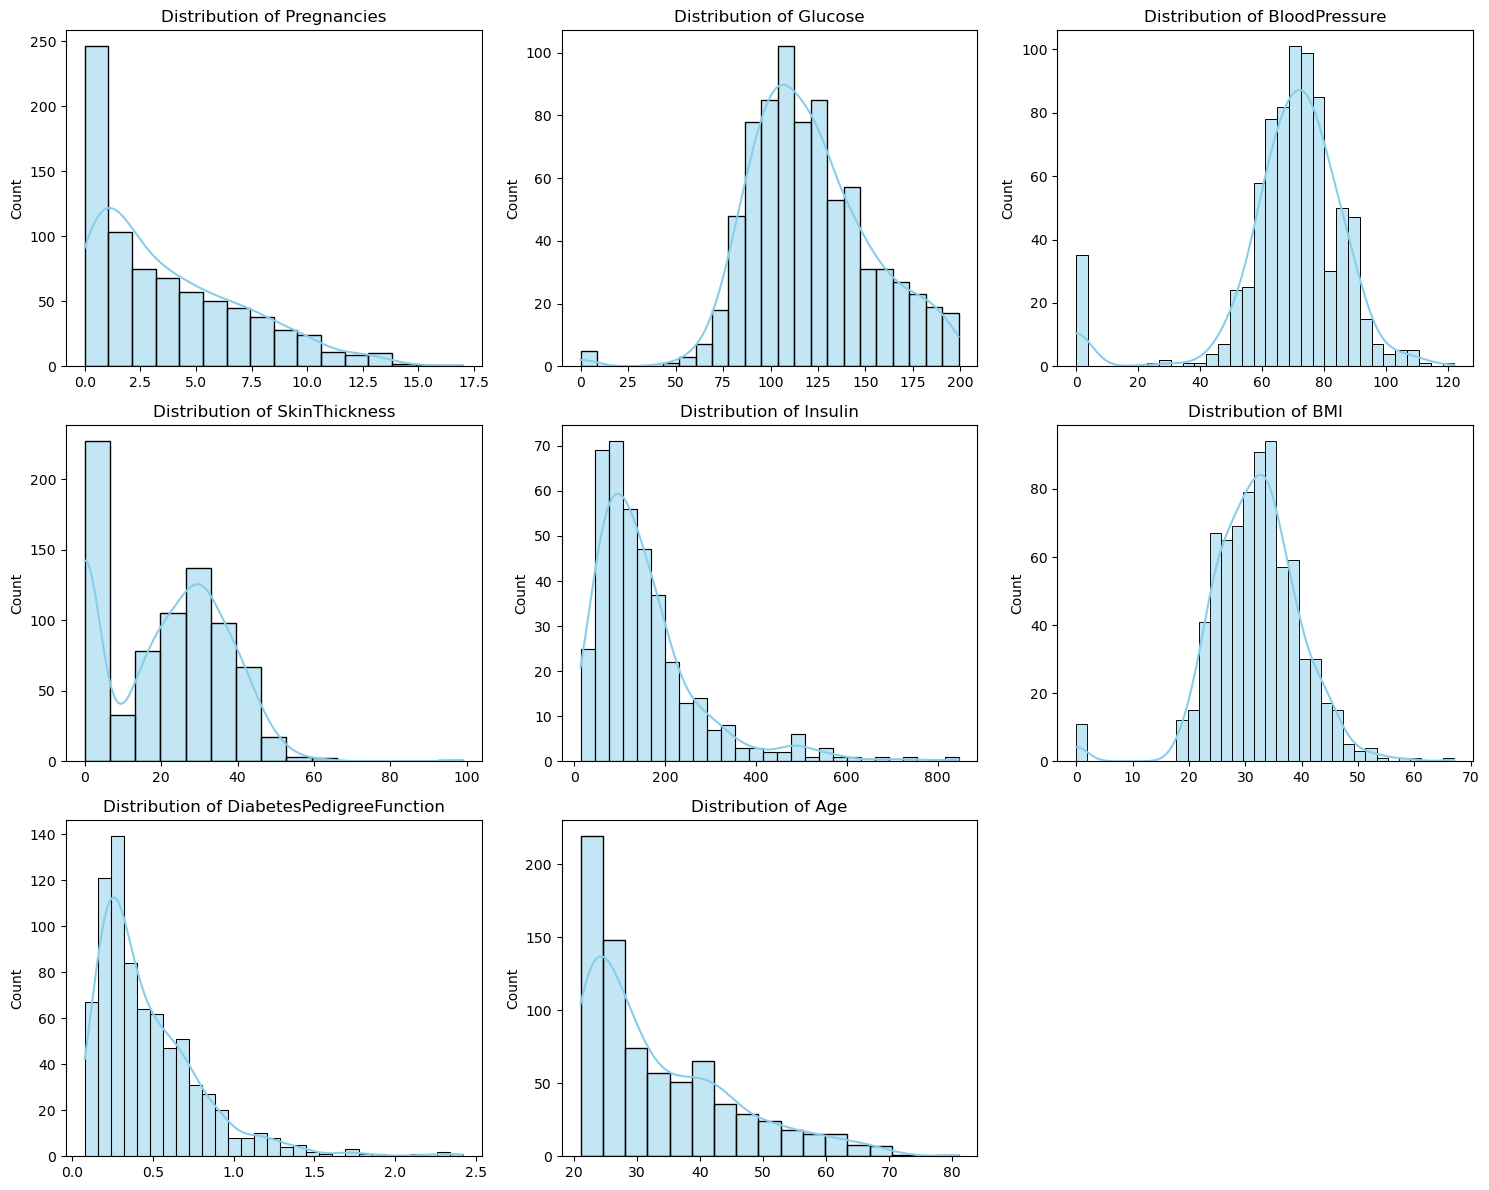

In [15]:
# for col in columns:

    
# plt.histplot(x=df[])
features = df.drop(columns = ['Outcome']).columns

fig, axes = plt.subplots(nrows=3,ncols=3,figsize=(15,12))
axes = axes.flatten()

# 4. Loop through features using index (idx) and column name (col)
for idx, col in enumerate(features):
    # Plot the histogram on the specific grid subplot
    sns.histplot(data=df, x=col, ax=axes[idx], kde=True, color='skyblue')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel('')  # Clears redundant x-labels for cleaner look

# 5. Hide any unused subplots (since we have 8 features but 9 grid slots)
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

# 6. Adjust layout so titles and labels don't overlap
plt.tight_layout()
plt.show()

In [17]:
corr_matrix = df.corr()

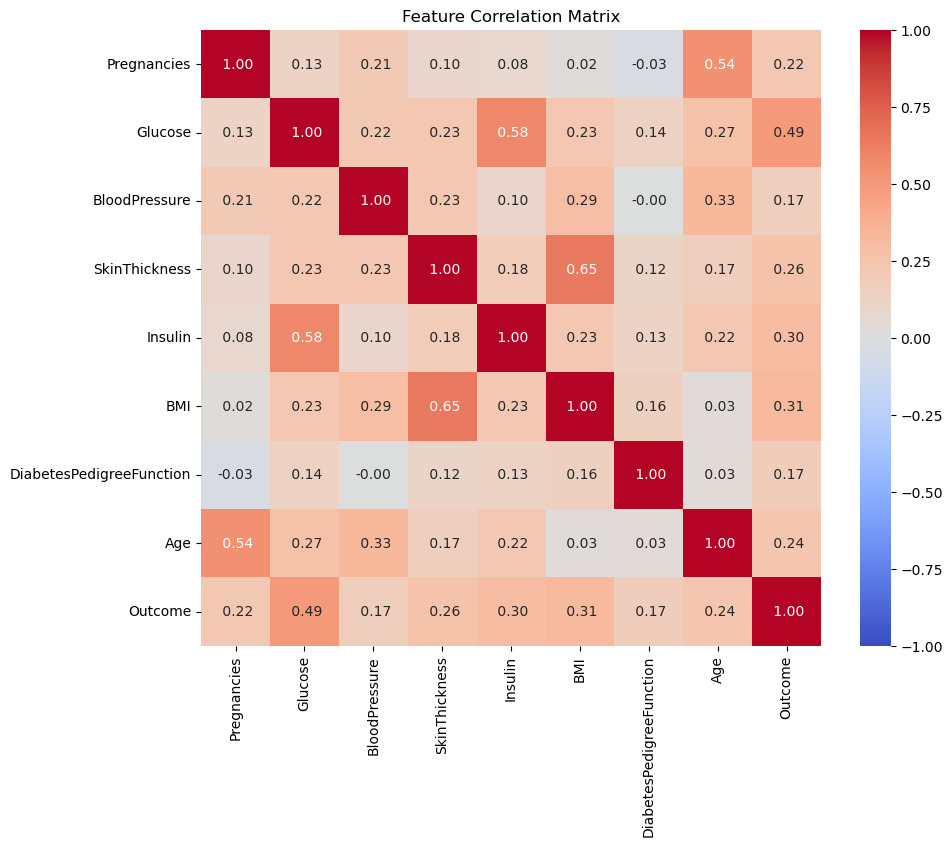

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True,fmt =" .2f",cmap = "coolwarm",vmin =-1,vmax =1)
plt.title("Feature Correlation Matrix")
plt.show()

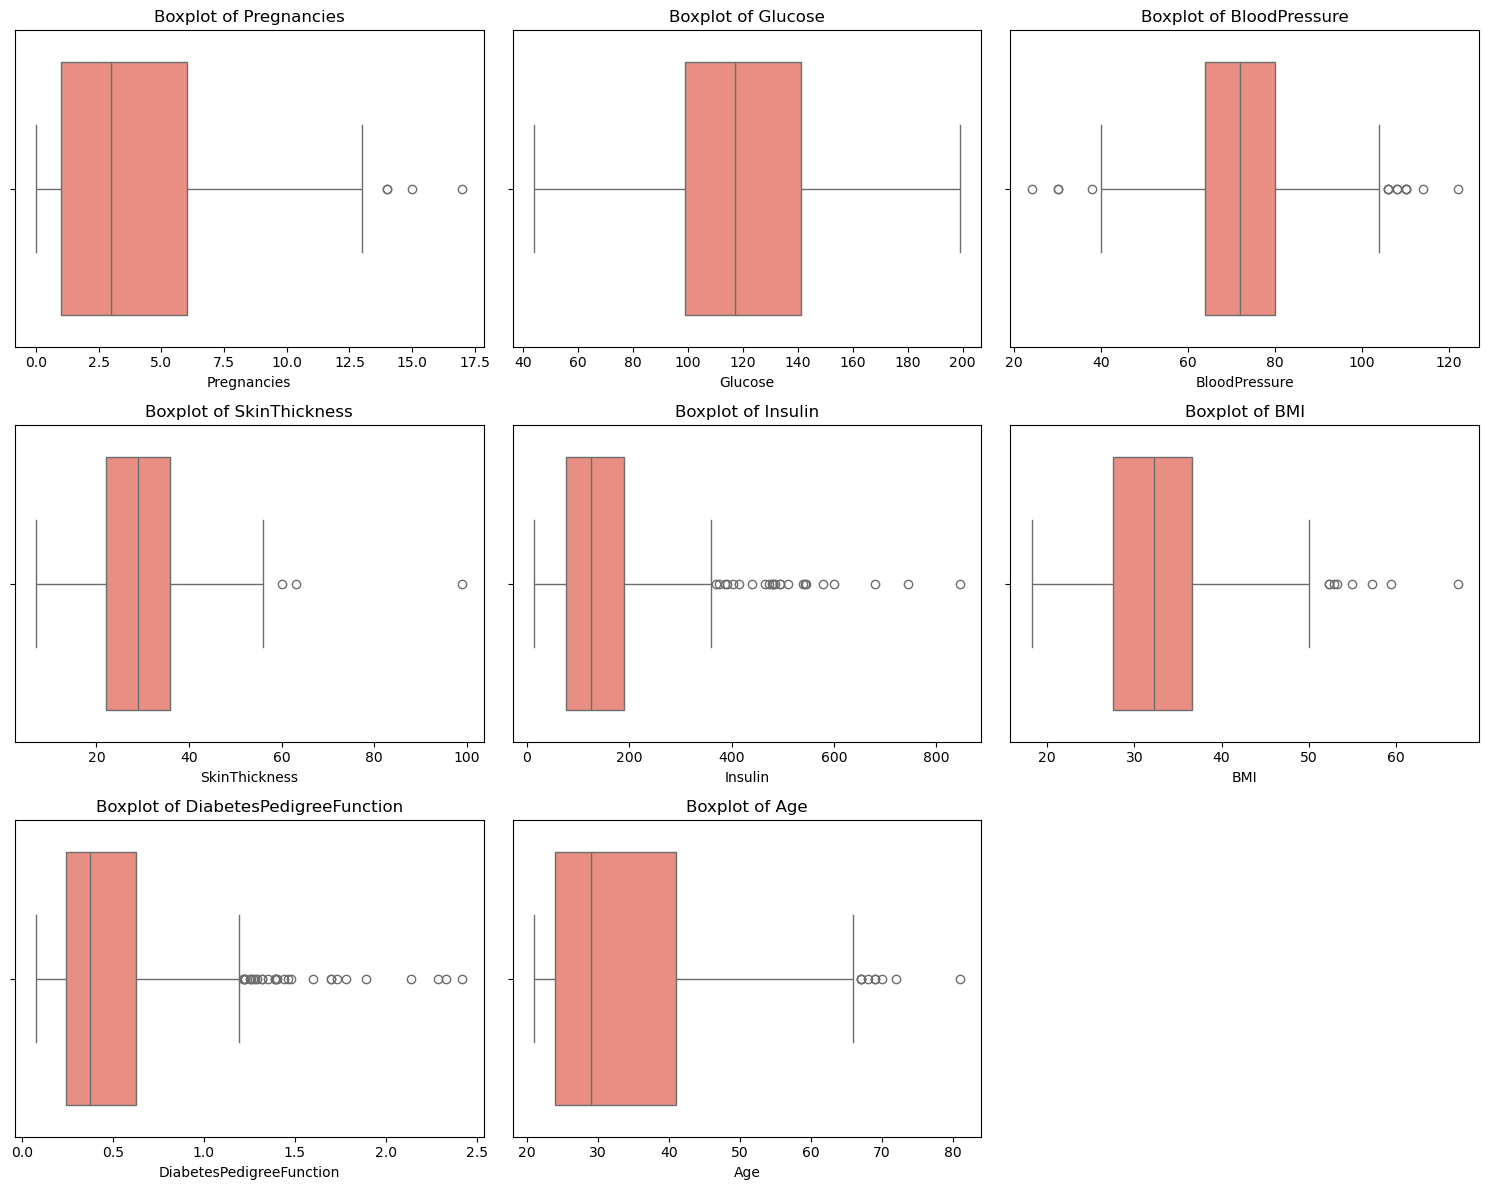

In [20]:
features = df.drop(columns = ['Outcome']).columns
fig,axes = plt.subplots(nrows = 3, ncols=3,figsize = (15,12))
axes = axes.flatten()

for idx,col in enumerate(features):
    sns.boxplot(data = df, x = col,ax = axes[idx],color='salmon')
    axes[idx].set_title(f'Boxplot of {col}')

# 4. Clean up the empty 9th slot
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [21]:
from sklearn.preprocessing import RobustScaler

In [22]:
X = df.drop(columns = ['Outcome']).copy()
y = df['Outcome']

In [23]:
X['DiabetesPedigreeFunction'] = np.log1p(X['DiabetesPedigreeFunction']) # log1p = log(x + 1)

# --- Step 2: Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 3: Imputation (Assuming your KNNImputer code runs here) ---
# ... (Apply your KNNImputer to handle the NaNs we fixed earlier) ...

# --- Step 4: Robust Scaling (Handles the BMI outliers cleanly) ---
scaler = RobustScaler()

# Fit on training, transform both to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
from sklearn.model_selection import GridSearchCV

In [34]:
pipeline_config = {
    "Logistic Regression" : {
        "model" : LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "C":[0.01,0.1,1,10],
            "penalty":["l2"],
            "class_weight":["balanced",None]
        }
    },
    "Support Vector Machine": {
        "model" : SVC(probability = True, random_state=42),
        "params" :{
            "C":[0.1,1,10],
            "kernel":["rbf","linear"],
            "class_weight":["balanced",None]
        }
    },
    "Random Forest":{
        "model": RandomForestClassifier(random_state=42),
        "params":{
            "n_estimators": [100, 200],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5],
            "class_weight": ["balanced", "balanced_subsample", None]
        
        }
    } ,
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 5]
        }
    }
}
# 2. Master loop to execute grid search for each model
best_estimators = {}
summary_results = []

for name, config in pipeline_config.items():
    print(f"🚀 Tuning hyperparameters for {name}...")
    
    # Initialize Grid Search for the current model
    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=5,
        scoring="roc_auc",  # Optimizes overall class separation space
        n_jobs=-1,
        verbose=0
    )
    
    # Fit on the processed training data
    grid.fit(X_train_scaled, y_train)
    
    # Extract the best model instance
    best_model = grid.best_estimator_
    best_estimators[name] = best_model  # Save for deployment/inference
    
    # Evaluate on hold-out Test Set
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
    
    # Log key production metrics
    summary_results.append({
        "Model": name,
        "Best Params": str(grid.best_params_),
        "Train ROC-AUC (CV)": grid.best_score_,
        "Test ROC-AUC": roc_auc_score(y_test, y_prob),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1-Score": f1_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Accuracy" : accuracy_score(y_test, y_pred)
    })

# 3. Convert results to a DataFrame for side-by-side comparison
perf_df = pd.DataFrame(summary_results).sort_values(by="Test Recall", ascending=False)


🚀 Tuning hyperparameters for Logistic Regression...
🚀 Tuning hyperparameters for Support Vector Machine...
🚀 Tuning hyperparameters for Random Forest...
🚀 Tuning hyperparameters for Gradient Boosting...


In [35]:
perf_df

,Model,Best Params,Train ROC-AUC (CV),Test ROC-AUC,Test Recall,Test F1-Score,Test Precision,Test Accuracy
2,Random Forest,"{'class_weight': 'balanced_subsample', 'max_de...",0.845993,0.831038,0.818182,0.692308,0.600000,0.740260
1,Support Vector Machine,"{'C': 1, 'class_weight': 'balanced', 'kernel':...",0.845779,0.795960,0.781818,0.666667,0.581081,0.720779
0,Logistic Regression,"{'C': 10, 'class_weight': 'balanced', 'penalty...",0.842110,0.818365,0.709091,0.634146,0.573529,0.707792
3,Gradient Boosting,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.842053,0.822681,0.654545,0.679245,0.705882,0.779221


In [36]:
import joblib

# Pivot to the highest accuracy winner
winning_gb_model = best_estimators["Gradient Boosting"]

# Save the Gradient Boosting model instead
joblib.dump(winning_gb_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "expected_features.pkl")

print("🚀 Deployment artifacts updated to use high-accuracy Gradient Boosting!")

🚀 Deployment artifacts updated to use high-accuracy Gradient Boosting!
